# 🎨 Seaborn for CA Professionals
**Beautiful Statistical Charts with Minimal Code**

---

**Pre-requisite:** Module 4 — Matplotlib  
**Estimated time:** 4–5 hours  
**Session structure:** Why Seaborn → What is Seaborn → Key Concepts → Hands-on → Dashboard

---

## 📋 Table of Contents

| Part | Section | Topic |
|------|---------|-------|
| **Part 1: Why Seaborn?** | 1 | What Matplotlib Cannot Do Easily |
| | 2 | What is Seaborn? — History & Design |
| **Part 2: Fundamentals** | 3 | Figure-level vs Axes-level Functions |
| | 4 | Tidy Data — The Format Seaborn Expects |
| | 5 | Seaborn Themes & Palettes |
| **Part 3: Hands-on** | 6 | Installing & Setup |
| | 7 | Seaborn Themes (Hands-on) |
| | 8 | Distribution Plots — histplot & kdeplot |
| | 9 | Box Plot — Outlier Detection |
| | 10 | Violin Plot — Distribution Shape |
| | 11 | Bar & Count Plots |
| | 12 | Heatmap — Correlation Matrix |
| | 13 | Pair Plot — Multi-variable Exploration |
| | 14 | Scatter with Regression |
| | 15 | FacetGrid — Charts by Category |
| | 16 | Seaborn + Matplotlib Together |
| **Part 4: Practice** | 17 | Practice Exercises |

---

## Part 1: Why Seaborn?

## Section 1: What Matplotlib Cannot Do Easily

You have just learned Matplotlib — Python's foundational chart library. Matplotlib gives you complete control. But "complete control" also means writing a lot of code for things that should be simple.

### The verbosity problem

Imagine you want a box plot showing salary ranges across 5 departments, coloured by grade, with automatic outlier flagging.

**In Matplotlib — approximately 25 lines:**
```python
fig, ax = plt.subplots(figsize=(12, 6))
departments = ['Finance', 'Operations', 'Sales', 'HR', 'IT']
grades = ['Junior', 'Mid', 'Senior', 'Lead']
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF5757']
# ... manually group data by dept and grade
# ... manually draw each boxplot with ax.boxplot()
# ... manually set flierprops, whiskerprops, medianprops
# ... manually add legend
# ... manually format axes
```

**In Seaborn — 1 line:**
```python
sns.boxplot(data=employees, x='Department', y='Annual_CTC', hue='Grade', palette='Set2')
```

### What Seaborn adds over Matplotlib

| Task | Matplotlib | Seaborn |
|------|-----------|--------|
| Grouped box plot | ~25 lines | 1 line |
| Correlation heatmap | ~20 lines | 2 lines |
| Distribution + KDE curve | ~10 lines | 1 line |
| Scatter with regression line | ~15 lines | 1 line |
| Multi-variable pair plot | ~30+ lines | 1 line |
| Category-split FacetGrid | ~20 lines | 3 lines |

### Seaborn is NOT a replacement for Matplotlib

Seaborn **builds on top of Matplotlib** — every Seaborn chart is a Matplotlib chart underneath. This means:

- You can always use Matplotlib commands to customise a Seaborn chart
- `fig, ax = plt.subplots()` still works — pass `ax=ax` to Seaborn functions
- `plt.show()`, `fig.savefig()` still save/display the chart

> **Think of Seaborn as Matplotlib with pre-built shortcuts for the most common statistical chart patterns.**

## Section 2: What is Seaborn? — History & Design

### The Origin Story

In **2012**, **Michael Waskom** was a graduate student at Stanford University (later a research scientist at NYU and Flatiron Institute). He was doing neuroscience research and found himself writing the same Matplotlib boilerplate code repeatedly for statistical visualizations.

He built a library of helper functions around Matplotlib and released it as **Seaborn** — named after the character **Sam Seaborn** from the TV show *The West Wing*.

> *"The goal of seaborn is to make a well-defined set of hard things easy."*  
> — Michael Waskom

Seaborn was open-sourced in 2012. Today it has over **30 million downloads per month** and is the standard library for statistical visualization in Python across academia, finance, and data science.

### Design philosophy

Seaborn was designed around three principles:

1. **Dataset-oriented API**: Pass the full DataFrame and column names — Seaborn figures out the groupings
2. **Statistical by default**: Automatically computes means, confidence intervals, distributions
3. **Beautiful by default**: Comes with tasteful colour palettes and clean themes out of the box

### Where Seaborn fits

```
┌──────────────────────────────────────────────────────────────────────────┐
│    Seaborn — statistical visualization, beautiful defaults               │ ← You are here
├──────────────────────────────────────────────────────────────────────────┤
│    Matplotlib — complete, low-level chart control                        │ ← Module 4
├──────────────────────────────────────────────────────────────────────────┤
│    NumPy / Pandas — the data underneath                                  │ ← Modules 2 & 3
└──────────────────────────────────────────────────────────────────────────┘
```

### Seaborn's strengths for CA professionals

| Analysis need | Seaborn chart |
|---------------|---------------|
| How are invoice amounts distributed? | `histplot` with KDE |
| Are there suspicious outliers in expenses? | `boxplot` — flags them automatically |
| Which financial ratios correlate? | `heatmap` on a correlation matrix |
| Do salaries differ by department? | `violinplot` or `boxplot` with `hue` |
| Is revenue growth statistically significant? | `regplot` with confidence band |
| Compare a metric across all departments × grade combinations | `FacetGrid` |

## Part 2: Seaborn Fundamentals

## Section 3: Figure-level vs Axes-level Functions

This is the **most important conceptual distinction** in Seaborn. Confusing these two types of functions is the most common source of errors.

### Axes-level functions

**Draw onto a specific Axes (subplot).** These are the functions you will use most often.

| Function | Chart type |
|----------|-----------|
| `sns.histplot()` | Histogram |
| `sns.kdeplot()` | Kernel density curve |
| `sns.boxplot()` | Box plot |
| `sns.violinplot()` | Violin plot |
| `sns.barplot()` | Bar chart with confidence intervals |
| `sns.countplot()` | Count bar chart |
| `sns.heatmap()` | Heatmap |
| `sns.regplot()` | Scatter with regression line |
| `sns.stripplot()` | Jittered strip plot |

**Key feature:** Accept an `ax=` parameter — so you can place them inside Matplotlib subplots.

```python
fig, axes = plt.subplots(1, 2)
sns.boxplot(data=df, x='Dept', y='Salary', ax=axes[0])   # goes in left subplot
sns.histplot(data=df, x='Amount', ax=axes[1])              # goes in right subplot
```

### Figure-level functions

**Create their own Figure and Axes internally.** These return a special grid object, not a Matplotlib Axes.

| Function | What it creates |
|----------|----------------|
| `sns.pairplot()` | Grid of scatter plots for all variable pairs |
| `sns.lmplot()` | Regression plot split by category |
| `sns.FacetGrid()` | Custom grid of any chart, split by category |
| `sns.catplot()` | Categorical plot (combines several axes-level functions) |
| `sns.displot()` | Distribution plot grid |

**Key feature:** Do NOT accept `ax=` — they manage their own Figure. You access the underlying Figure via `.fig`.

```python
g = sns.pairplot(df)           # g is a PairGrid object
g.fig.suptitle('Pair Plot')    # access Figure like this
```

### The rule

> **Use axes-level functions** when you want to place a chart in a specific subplot of a larger dashboard.  
> **Use figure-level functions** when you want a standalone exploratory chart (pairplot, FacetGrid, lmplot).

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/4191714505.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x='Quarter', y='Revenue', ax=axes[0], palette='Blues_d')


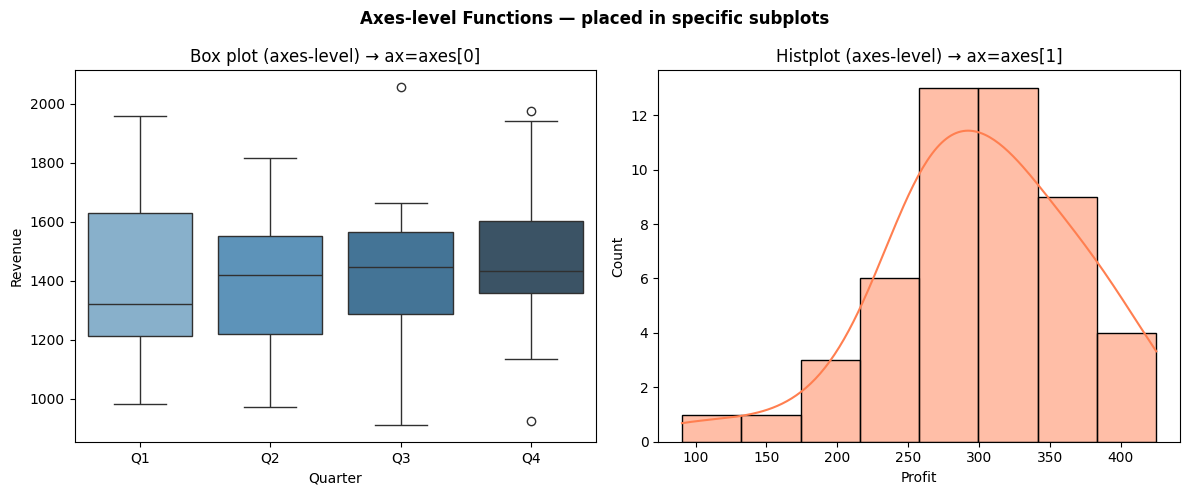

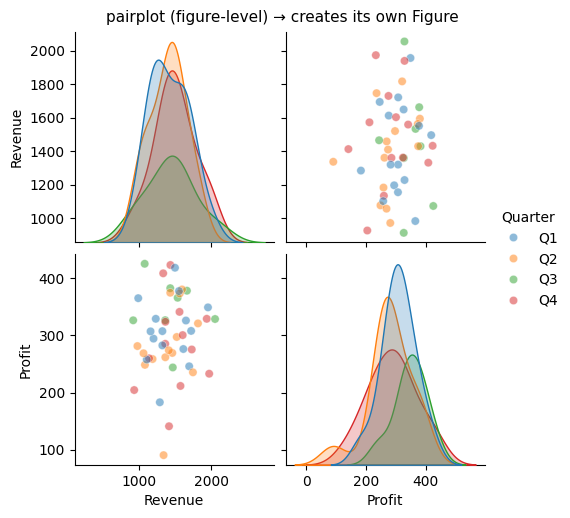

Axes-level return type: <class 'matplotlib.axes._axes.Axes'>
Figure-level return type: <class 'seaborn.axisgrid.PairGrid'>


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Demonstrating axes-level vs figure-level ---

# Build a small sample
np.random.seed(42)
sample = pd.DataFrame({
    'Revenue': np.random.normal(1500, 300, 50),
    'Profit':  np.random.normal(300, 80, 50),
    'Quarter': np.random.choice(['Q1','Q2','Q3','Q4'], 50)
})

# AXES-LEVEL: can be placed in a subplot grid using ax=
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Axes-level Functions — placed in specific subplots', fontsize=12, fontweight='bold')

sns.boxplot(data=sample, x='Quarter', y='Revenue', ax=axes[0], palette='Blues_d')
axes[0].set_title('Box plot (axes-level) → ax=axes[0]')

sns.histplot(data=sample, x='Profit', kde=True, ax=axes[1], color='coral')
axes[1].set_title('Histplot (axes-level) → ax=axes[1]')

plt.tight_layout()
plt.show()

# FIGURE-LEVEL: creates its own figure, returns a Grid object
g = sns.pairplot(sample, hue='Quarter', height=2.5, plot_kws={'alpha': 0.5})
g.fig.suptitle('pairplot (figure-level) → creates its own Figure', y=1.02, fontsize=11)
plt.show()

print("Axes-level return type:", type(axes[0]))  # AxesSubplot
print("Figure-level return type:", type(g))       # PairGrid

## Section 4: Tidy Data — The Format Seaborn Expects

### What is tidy data?

Seaborn is designed to work with **tidy (long) format** DataFrames. Understanding this format is essential — it determines how you pass data to Seaborn.

**Tidy data rules** (Hadley Wickham, 2014):
1. Each variable is in its own **column**
2. Each observation is in its own **row**
3. Each observational unit forms a **table**

### Long format vs Wide format — the key distinction

**Wide format** (how we often store data in Excel):
```
Month  | Revenue  | COGS    | Net_Profit
-------|----------|---------|----------
Apr    | 1250000  | 750000  | 197000
May    | 1380000  | 828000  | 229000
Jun    | 1120000  | 672000  | 185000
```

**Long (tidy) format** (what Seaborn loves):
```
Month  | Metric      | Value
-------|-------------|--------
Apr    | Revenue     | 1250000
Apr    | COGS        | 750000
Apr    | Net_Profit  | 197000
May    | Revenue     | 1380000
...
```

In the long format, `Month` and `Metric` are variables (columns), and `Value` is the observed value. Seaborn can now automatically group by `Metric` and colour bars differently — with a single `hue='Metric'` argument.

### Converting between formats

| Direction | Pandas method |
|-----------|--------------|
| Wide → Long | `pd.melt()` |
| Long → Wide | `df.pivot_table()` or `df.pivot()` |

### When to use which format

- **Wide format**: Pivot tables, Excel exports, DataFrames where each column is a distinct metric
- **Long format**: Seaborn charts, GroupBy operations, any analysis that treats metrics as a category

Wide format (from Excel):
  Month  Revenue  COGS  Net_Profit
0   Apr     1250   750         197
1   May     1380   828         229
2   Jun     1120   672         185

Long (tidy) format after melt():
Month     Metric  Amount
  Apr    Revenue    1250
  Apr Net_Profit     197
  Apr       COGS     750
  May    Revenue    1380
  May Net_Profit     229
  May       COGS     828
  Jun    Revenue    1120
  Jun Net_Profit     185
  Jun       COGS     672


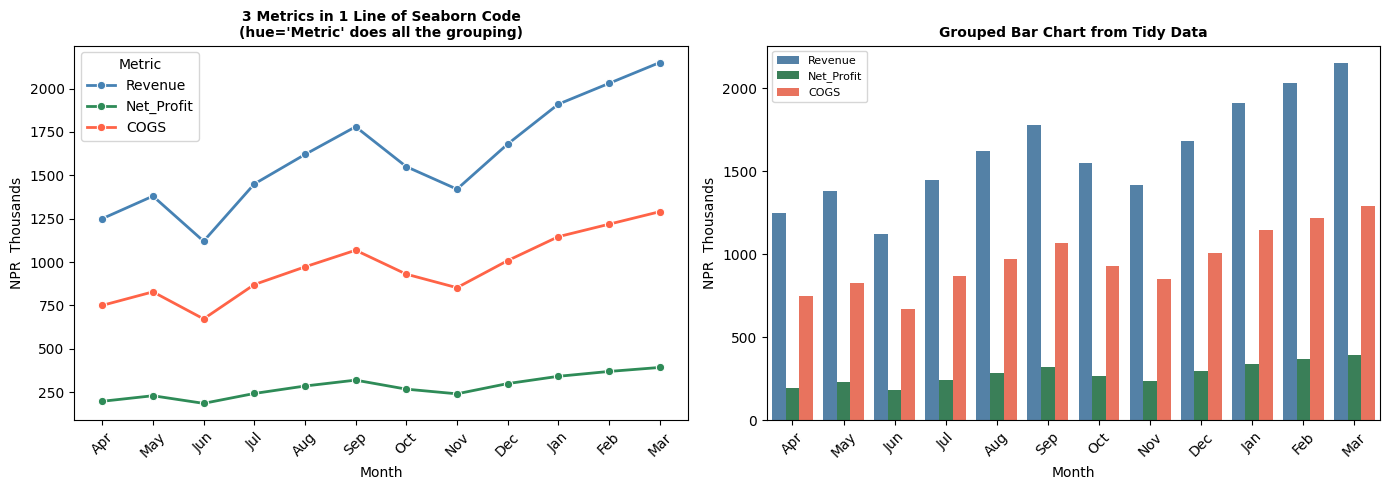

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Wide format (typical of what you'd import from Excel) ---
wide_df = pd.DataFrame({
    'Month':      ['Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar'],
    'Revenue':    [1250, 1380, 1120, 1450, 1620, 1780, 1550, 1420, 1680, 1910, 2030, 2150],
    'COGS':       [ 750,  828,  672,  870,  972, 1068,  930,  852, 1008, 1146, 1218, 1290],
    'Net_Profit': [ 197,  229,  185,  242,  285,  319,  267,  240,  299,  341,  369,  392],
})

print("Wide format (from Excel):")
print(wide_df.head(3))

# --- Convert to Long (tidy) format using pd.melt() ---
long_df = wide_df.melt(
    id_vars=['Month'],              # columns to keep as-is
    value_vars=['Revenue', 'COGS', 'Net_Profit'],   # columns to "unpivot"
    var_name='Metric',              # new column name for the former column headers
    value_name='Amount'             # new column name for the values
)

# Fix month order for charts (Apr → Mar, not alphabetical)
month_order = ['Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar']
long_df['Month'] = pd.Categorical(long_df['Month'], categories=month_order, ordered=True)
long_df = long_df.sort_values('Month')

print("\nLong (tidy) format after melt():")
print(long_df.head(9).to_string(index=False))

# --- Seaborn works beautifully with long format ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# One line draws all 3 metrics, coloured automatically
sns.lineplot(data=long_df, x='Month', y='Amount', hue='Metric', ax=axes[0],
             palette={'Revenue':'steelblue','COGS':'tomato','Net_Profit':'seagreen'},
             marker='o', linewidth=2)
axes[0].set_title('3 Metrics in 1 Line of Seaborn Code\n(hue=\'Metric\' does all the grouping)',
                  fontsize=10, fontweight='bold')
axes[0].set_ylabel('NPR  Thousands')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart split by metric
sns.barplot(data=long_df, x='Month', y='Amount', hue='Metric', ax=axes[1],
            palette={'Revenue':'steelblue','COGS':'tomato','Net_Profit':'seagreen'})
axes[1].set_title('Grouped Bar Chart from Tidy Data', fontsize=10, fontweight='bold')
axes[1].set_ylabel('NPR  Thousands')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Section 5: Seaborn Themes & Palettes

One of Seaborn's most valued features is its built-in themes and colour palettes. One line of code transforms the look of every chart in your notebook.

### Built-in themes

| Theme | Look | Use when |
|-------|------|---------|
| `whitegrid` | White background, grey grid lines | Presentations, reports (most readable) |
| `darkgrid` | Dark background, grid lines | Technical reports, dark-mode screens |
| `white` | White background, no grid | Clean, minimal publications |
| `ticks` | White background, tick marks only | Academic papers |
| `dark` | Dark background, no grid | Rarely used |

**Set globally** (affects all subsequent charts):
```python
sns.set_theme(style='whitegrid', palette='deep')
```

**Set for one block only:**
```python
with sns.axes_style('darkgrid'):
    sns.histplot(...)   # only this chart uses darkgrid
```

### Built-in colour palettes

| Palette | Type | Use when |
|---------|------|---------|
| `deep` (default) | Categorical | Different categories, no order |
| `Blues`, `Reds`, `Greens` | Sequential | Ordered data (low → high) |
| `RdYlGn` | Diverging | Data centred at zero (profit/loss, variance) |
| `colorblind` | Categorical | Presentations with accessibility needs |
| `husl` | Categorical | Many categories (> 6) |
| `rocket`, `mako` | Sequential | Modern, perceptually uniform |

### Finance colour conventions in Seaborn

```python
# For profit/loss charts — diverging palette centred at zero
sns.heatmap(data, cmap='RdYlGn', center=0)

# For variance (positive=good, negative=bad)
palette = {True: 'seagreen', False: 'tomato'}

# For categories (departments, expense heads)
sns.set_palette('deep')   # or 'colorblind' for accessible reports
```

> **Rule of thumb:** Use `whitegrid` for all classroom and client-facing charts. It's the cleanest, most universally readable theme.

## Part 3: Hands-on with Seaborn

## Section 6: Installing & Setup

In [3]:
# Install if needed
# !pip install seaborn matplotlib pandas numpy

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

print('Seaborn version:', sns.__version__)
print('Ready!')

Seaborn version: 0.13.2
Ready!


In [4]:
# ==== Build a rich financial dataset for this notebook ====
np.random.seed(42)

n = 200   # 200 employee records

departments = np.random.choice(['Finance', 'Operations', 'Sales', 'HR', 'IT'], n,
                                p=[0.20, 0.25, 0.30, 0.10, 0.15])
grades      = np.random.choice(['Junior', 'Mid', 'Senior', 'Lead'], n, p=[0.35, 0.30, 0.25, 0.10])

base_salary = {'Junior': 280000, 'Mid': 480000, 'Senior': 720000, 'Lead': 1080000}
salaries = np.array([base_salary[g] * np.random.uniform(0.85, 1.25) for g in grades])

experience  = np.array([{'Junior': 1.5, 'Mid': 4.0, 'Senior': 8.0, 'Lead': 12.0}[g] +
                         np.random.uniform(-1, 2) for g in grades]).clip(0, 20)
performance = np.clip(np.random.normal(3.2, 0.8, n), 1, 5).round(1)
bonus_pct   = np.clip(performance * 2.5 + np.random.uniform(-2, 3, n), 5, 25).round(1)
bonus_amt   = salaries * bonus_pct / 100

employees = pd.DataFrame({
    'Department': departments,
    'Grade':      grades,
    'Annual_CTC': salaries.round(0).astype(int),
    'Experience': experience.round(1),
    'Perf_Score': performance,
    'Bonus_Pct':  bonus_pct,
    'Bonus_Amt':  bonus_amt.round(0).astype(int),
})

# Invoice dataset
np.random.seed(7)
m = 300
invoice_df = pd.DataFrame({
    'Amount':    np.random.exponential(75000, m).clip(5000, 600000).round(-3).astype(int),
    'Category':  np.random.choice(['Materials', 'Services', 'Utilities', 'Travel', 'Misc'], m,
                                    p=[0.30, 0.25, 0.15, 0.20, 0.10]),
    'Month':     np.random.choice(['Apr','May','Jun','Jul','Aug','Sep',
                                    'Oct','Nov','Dec','Jan','Feb','Mar'], m),
    'VAT_Rate': np.random.choice([0, 13], m, p=[0.15, 0.85]),
    'Status':    np.random.choice(['Paid', 'Pending', 'Overdue'], m, p=[0.65, 0.25, 0.10]),
})

print(f'Employee dataset: {employees.shape[0]} records')
print(f'Invoice dataset:  {invoice_df.shape[0]} records')
print()
print(employees.head())

Employee dataset: 200 records
Invoice dataset:  300 records

   Department   Grade  Annual_CTC  Experience  Perf_Score  Bonus_Pct  \
0  Operations     Mid      427800         3.5         2.6        9.2   
1          IT  Junior      339086         1.3         3.6       11.0   
2       Sales  Junior      294588         1.0         4.7       14.7   
3       Sales  Senior      850020         7.3         4.3       10.5   
4     Finance     Mid      469450         3.4         4.5       13.1   

   Bonus_Amt  
0      39358  
1      37299  
2      43304  
3      89252  
4      61498  


## Section 7: Seaborn Themes

Seaborn gives you ready-made, professional themes. Just one line changes the look of all your charts.

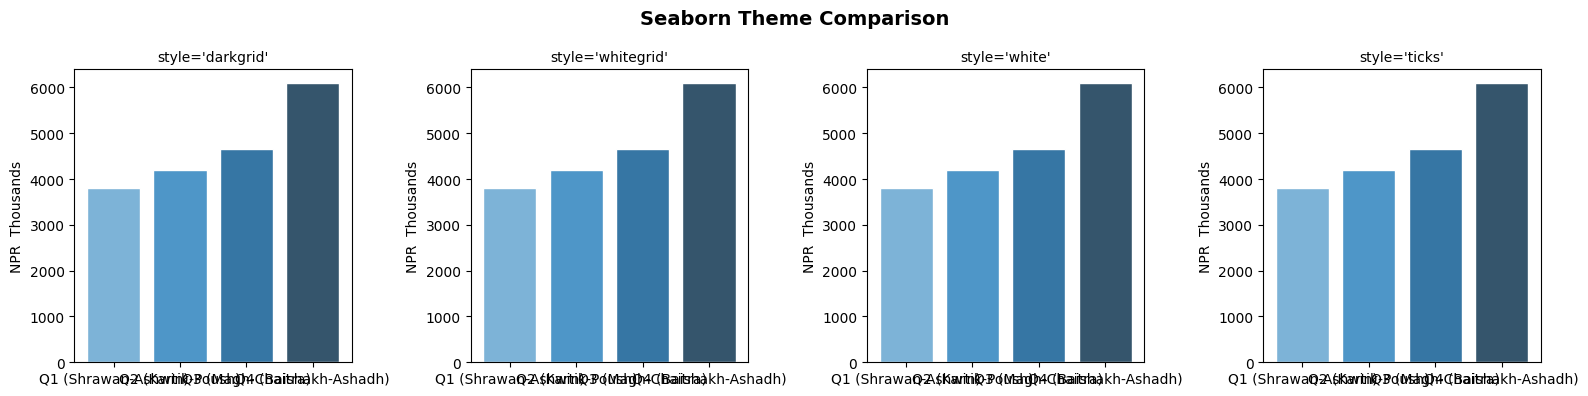

Default theme set to 'whitegrid' with 'deep' palette


In [5]:
# Available themes: darkgrid, whitegrid, dark, white, ticks
# Available palettes: deep, muted, bright, pastel, dark, colorblind, Blues, rocket, etc.

themes = ['darkgrid', 'whitegrid', 'white', 'ticks']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Seaborn Theme Comparison', fontsize=14, fontweight='bold')

sample_x = ['Q1 (Shrawan-Ashwin)', 'Q2 (Kartik-Poush)', 'Q3 (Magh-Chaitra)', 'Q4 (Baishakh-Ashadh)']
sample_y = [3800, 4200, 4650, 6090]

for ax, theme in zip(axes, themes):
    with sns.axes_style(theme):
        ax.bar(sample_x, sample_y, color=sns.color_palette('Blues_d', 4))
        ax.set_title(f"style='{theme}'", fontsize=10)
        ax.set_ylabel('NPR  Thousands')

plt.tight_layout()
plt.show()

# Set a default theme for the rest of this notebook
sns.set_theme(style='whitegrid', palette='deep')
print("Default theme set to 'whitegrid' with 'deep' palette")

## Section 8: Distribution Plots — histplot & kdeplot

Distribution plots answer: *"How are my values spread?"*  

For CA professionals: *"Are most invoices small, or are large invoices common?"*  
*"Are salaries concentrated in one band or spread across many?"*

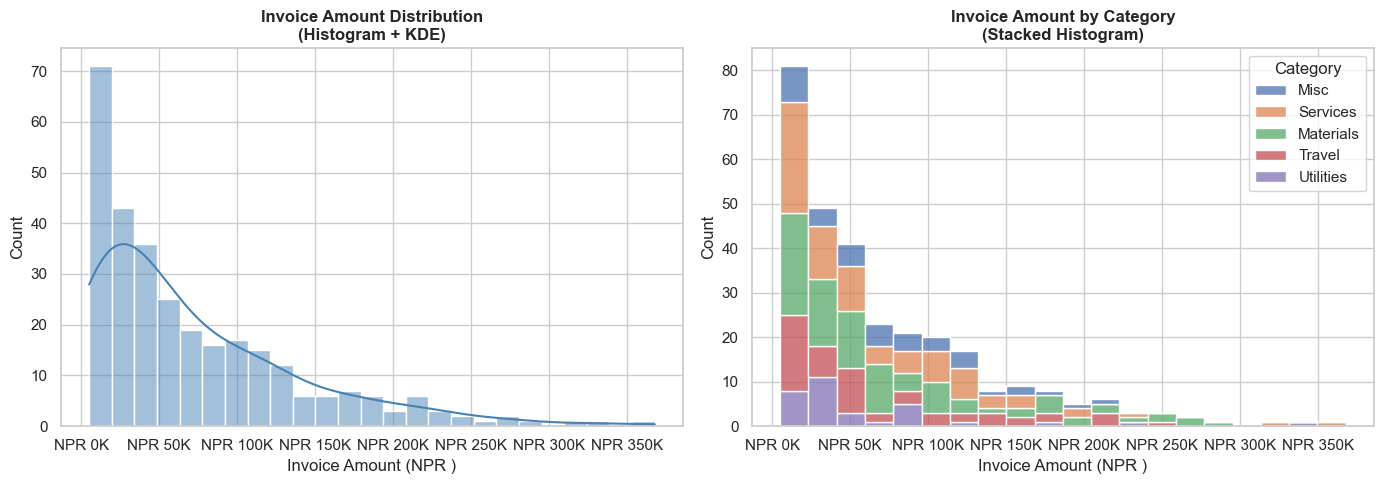

In [6]:
# histplot — distribution of invoice amounts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple histogram
sns.histplot(data=invoice_df, x='Amount', bins=25, color='steelblue',
             kde=True, ax=axes[0])
axes[0].set_title('Invoice Amount Distribution\n(Histogram + KDE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Invoice Amount (NPR )')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'NPR {x/1000:.0f}K'))

# Histogram by Category
sns.histplot(data=invoice_df, x='Amount', hue='Category', bins=20,
             multiple='stack', ax=axes[1])
axes[1].set_title('Invoice Amount by Category\n(Stacked Histogram)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Invoice Amount (NPR )')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'NPR {x/1000:.0f}K'))

plt.tight_layout()
plt.show()

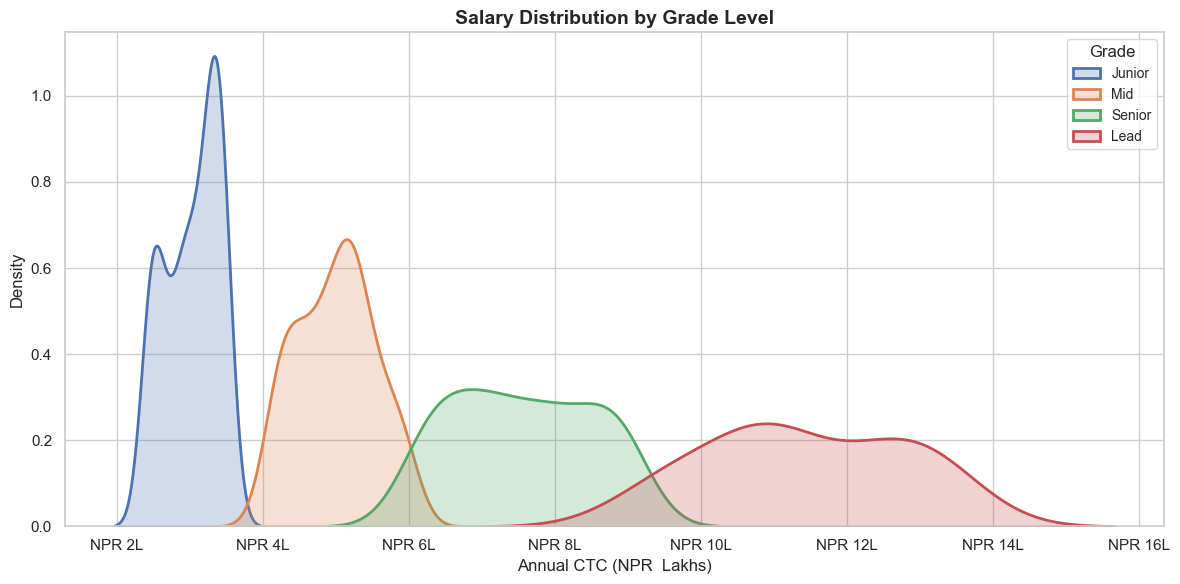

Average CTC by Grade:
Grade
Junior     NPR 3.0 Lakhs
Mid        NPR 5.0 Lakhs
Senior     NPR 7.6 Lakhs
Lead      NPR 11.4 Lakhs
Name: Annual_CTC, dtype: object


In [7]:
# kdeplot — Salary distribution by Grade (smooth density curves)
fig, ax = plt.subplots(figsize=(12, 6))

for grade in ['Junior', 'Mid', 'Senior', 'Lead']:
    subset = employees[employees['Grade'] == grade]['Annual_CTC']
    sns.kdeplot(subset / 100000, label=grade, fill=True, alpha=0.25, linewidth=2, ax=ax)

ax.set_title('Salary Distribution by Grade Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual CTC (NPR  Lakhs)')
ax.set_ylabel('Density')
ax.legend(title='Grade', fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'NPR {x:.0f}L'))

plt.tight_layout()
plt.show()

print('Average CTC by Grade:')
print(employees.groupby('Grade')['Annual_CTC'].mean().sort_values().apply(lambda x: f'NPR {x/100000:.1f} Lakhs'))

## Section 9: Box Plot — Outlier Detection

Box plots are **one of the most important charts for auditors**.  
They show the spread of data and immediately highlight **outliers** — unusual values that may warrant investigation.

**Reading a box plot:**
```
         Outlier ●
              |
   Whisker ───┤ Upper fence (Q3 + 1.5×IQR)
              │
   Q3    ┌────┤ 75th percentile
         │    │
   Median├────┤ 50th percentile (orange line)
         │    │
   Q1    └────┤ 25th percentile
              │
   Whisker ───┤ Lower fence (Q1 - 1.5×IQR)
              |
         Outlier ●
```

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/888267004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=invoice_df, x='Category', y='Amount',
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/888267004.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employees, x='Department', y='Annual_CTC',


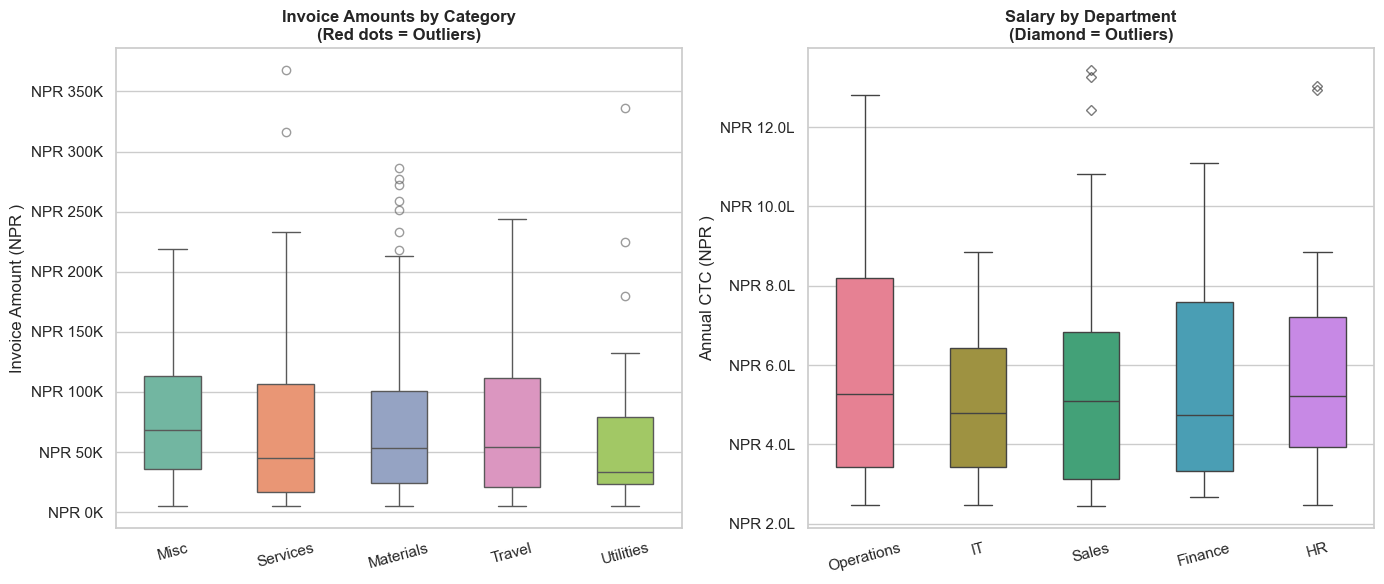

In [8]:
# Box plot — Invoice amounts by category (flags outliers automatically)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Invoice amounts by expense category
sns.boxplot(data=invoice_df, x='Category', y='Amount',
            palette='Set2', ax=axes[0], width=0.5,
            flierprops=dict(marker='o', color='red', markersize=6, alpha=0.6))
axes[0].set_title('Invoice Amounts by Category\n(Red dots = Outliers)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Invoice Amount (NPR )')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=15)

# Employee salary by department
sns.boxplot(data=employees, x='Department', y='Annual_CTC',
            palette='husl', ax=axes[1], width=0.5,
            flierprops=dict(marker='D', color='red', markersize=5, alpha=0.7))
axes[1].set_title('Salary by Department\n(Diamond = Outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Annual CTC (NPR )')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.1f}L'))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/660531211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employees, x='Grade', y='Annual_CTC',


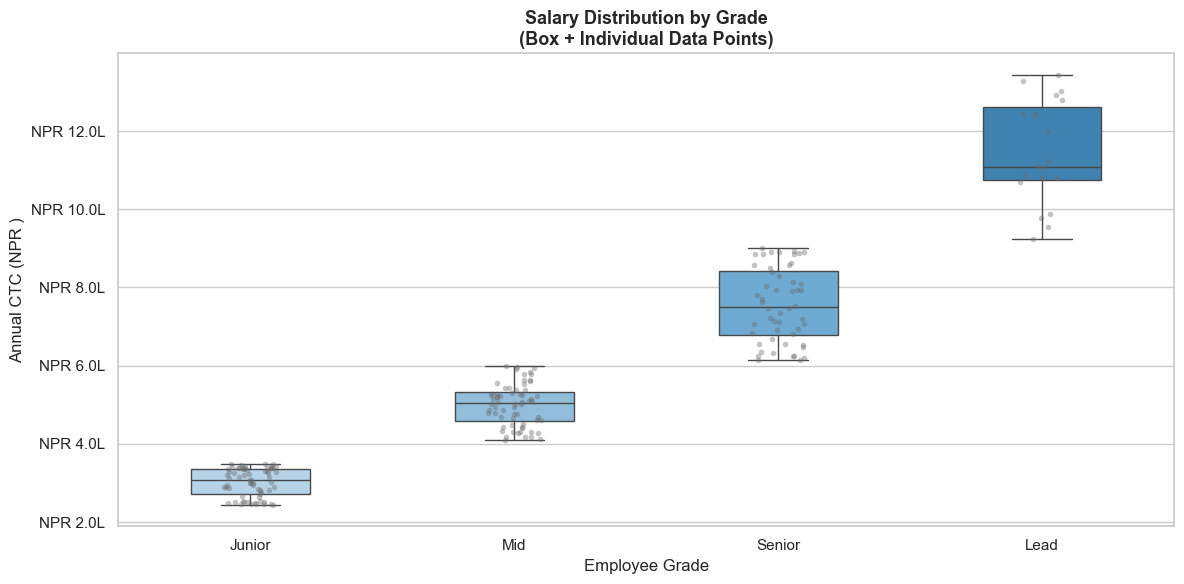

In [9]:
# Box plot with stripplot overlaid — shows individual data points
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=employees, x='Grade', y='Annual_CTC',
            order=['Junior', 'Mid', 'Senior', 'Lead'],
            palette=['#AED6F1','#85C1E9','#5DADE2','#2E86C1'],
            width=0.45, ax=ax,
            flierprops=dict(marker='', alpha=0))

sns.stripplot(data=employees, x='Grade', y='Annual_CTC',
              order=['Junior', 'Mid', 'Senior', 'Lead'],
              color='dimgray', alpha=0.4, size=4, jitter=True, ax=ax)

ax.set_title('Salary Distribution by Grade\n(Box + Individual Data Points)', fontsize=13, fontweight='bold')
ax.set_ylabel('Annual CTC (NPR )')
ax.set_xlabel('Employee Grade')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.1f}L'))

plt.tight_layout()
plt.show()

## Section 10: Violin Plot — Distribution Shape by Category

A **violin plot** combines a box plot with a KDE — it shows both summary statistics AND the full distribution shape.

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/3679463453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=employees, x='Department', y='Annual_CTC',


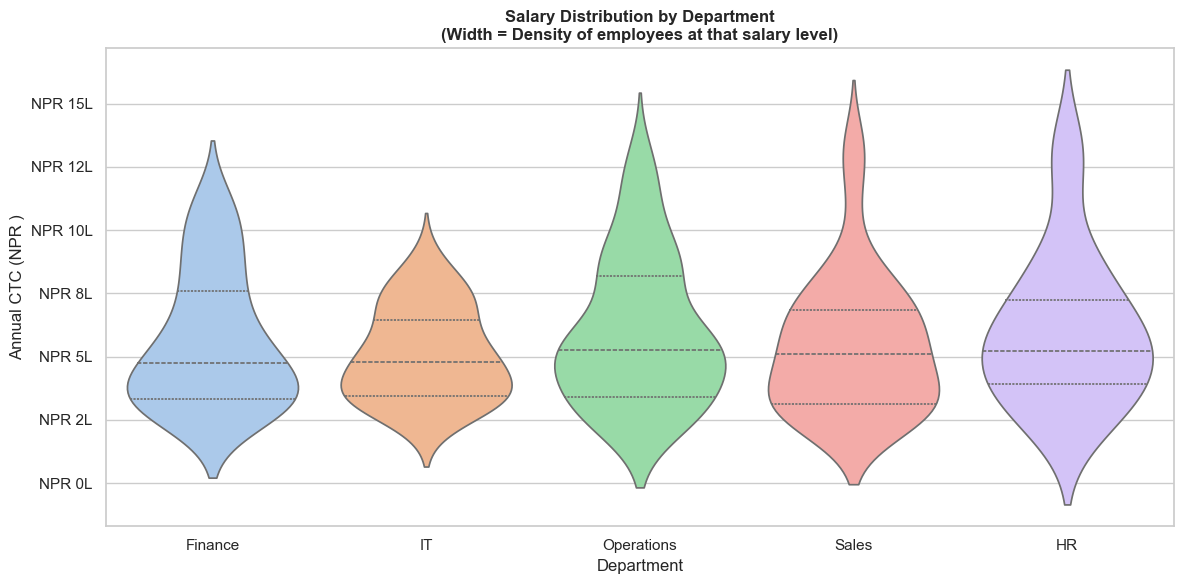

In [10]:
# Violin plot — salary distribution by department
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=employees, x='Department', y='Annual_CTC',
               palette='pastel', inner='quartile', ax=ax,
               order=['Finance', 'IT', 'Operations', 'Sales', 'HR'])

ax.set_title('Salary Distribution by Department\n(Width = Density of employees at that salary level)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Annual CTC (NPR )')
ax.set_xlabel('Department')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.0f}L'))

plt.tight_layout()
plt.show()

## Section 11: Bar & Count Plots — Category Analysis

`sns.barplot()` automatically calculates and displays **mean + confidence interval** for each category — more insightful than plain bar charts.

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/3403452037.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=employees, x='Department', y='Annual_CTC',
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/3403452037.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=employees, x='Grade', y='Bonus_Pct',


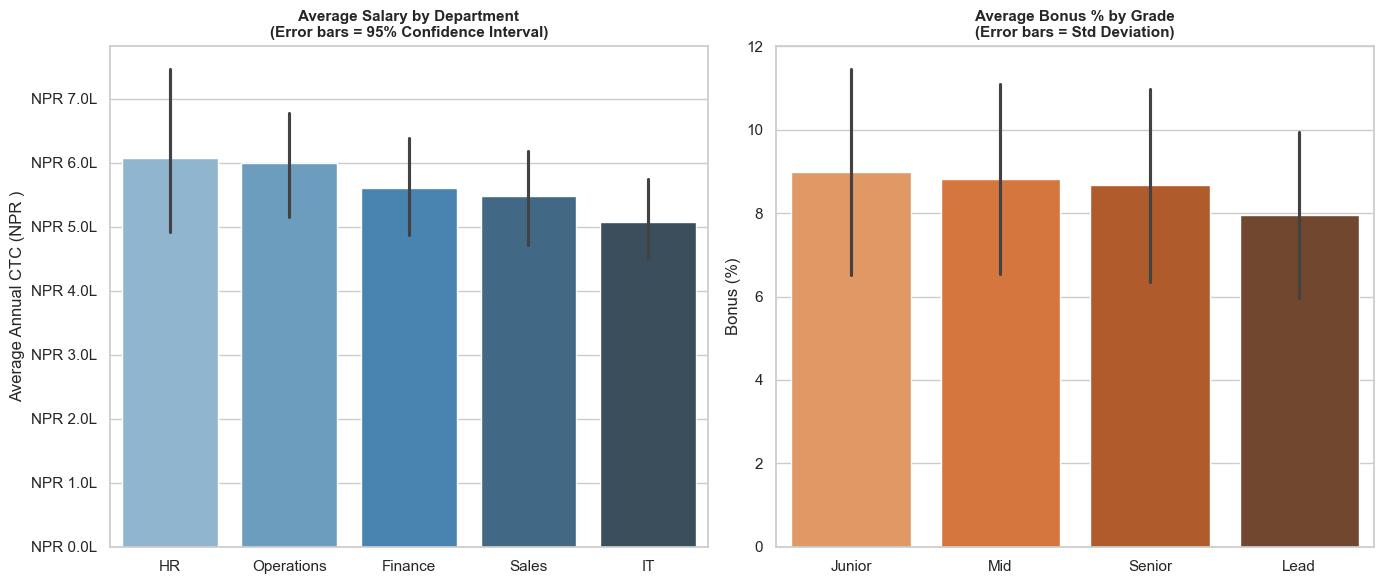

In [11]:
# barplot — Average salary by Department (with confidence interval)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average CTC by department
dept_order = employees.groupby('Department')['Annual_CTC'].mean().sort_values(ascending=False).index
sns.barplot(data=employees, x='Department', y='Annual_CTC',
            order=dept_order, palette='Blues_d',
            estimator='mean', errorbar='ci', ax=axes[0])
axes[0].set_title('Average Salary by Department\n(Error bars = 95% Confidence Interval)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Annual CTC (NPR )')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.1f}L'))

# Average bonus by Grade
grade_order = ['Junior', 'Mid', 'Senior', 'Lead']
sns.barplot(data=employees, x='Grade', y='Bonus_Pct',
            order=grade_order, palette='Oranges_d',
            ax=axes[1], errorbar='sd')
axes[1].set_title('Average Bonus % by Grade\n(Error bars = Std Deviation)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Bonus (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/4118093210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=invoice_df, x='Status',


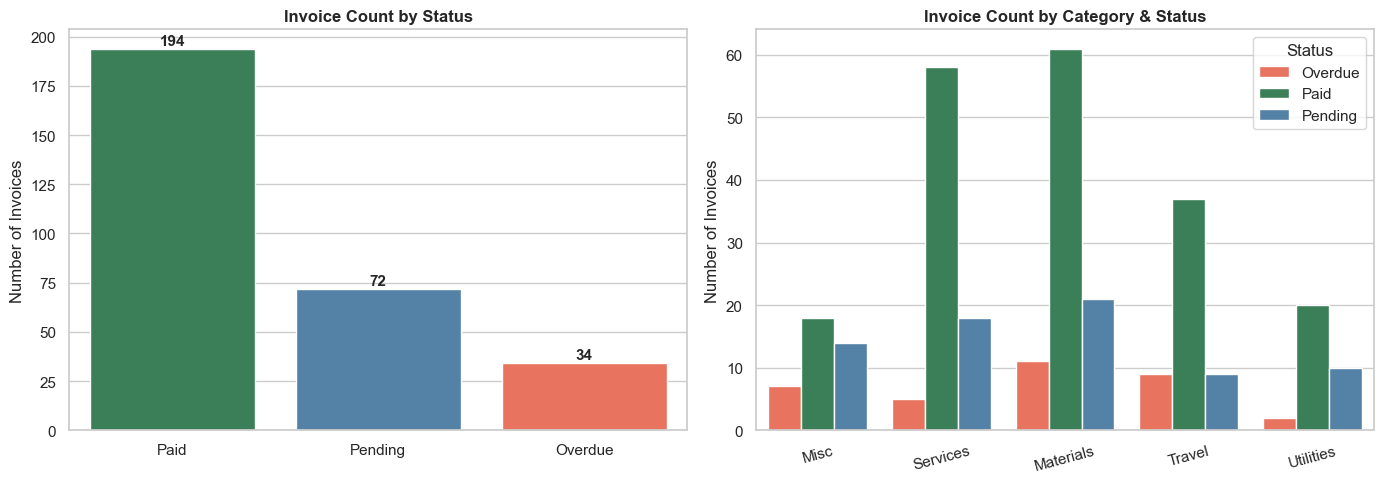

In [12]:
# countplot — how many invoices by status and category?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of invoices by status
sns.countplot(data=invoice_df, x='Status',
              palette={'Paid': 'seagreen', 'Pending': 'steelblue', 'Overdue': 'tomato'},
              order=['Paid', 'Pending', 'Overdue'], ax=axes[0])
axes[0].set_title('Invoice Count by Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Invoices')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 2),
                     ha='center', fontsize=11, fontweight='bold')

# Count by category and status (hue)
sns.countplot(data=invoice_df, x='Category', hue='Status',
              palette={'Paid': 'seagreen', 'Pending': 'steelblue', 'Overdue': 'tomato'},
              ax=axes[1])
axes[1].set_title('Invoice Count by Category & Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Invoices')
axes[1].set_xlabel('')
axes[1].legend(title='Status')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Section 12: Heatmap — Correlation Matrix

A **correlation heatmap** shows how strongly pairs of variables are related.  
In finance: *"Does revenue growth correlate with headcount?"* *"Are salaries correlated with performance?"*

**Correlation values:**
- `+1.0` = Perfect positive relationship (as one rises, the other rises)
- `0.0`  = No relationship
- `-1.0` = Perfect negative relationship (as one rises, the other falls)

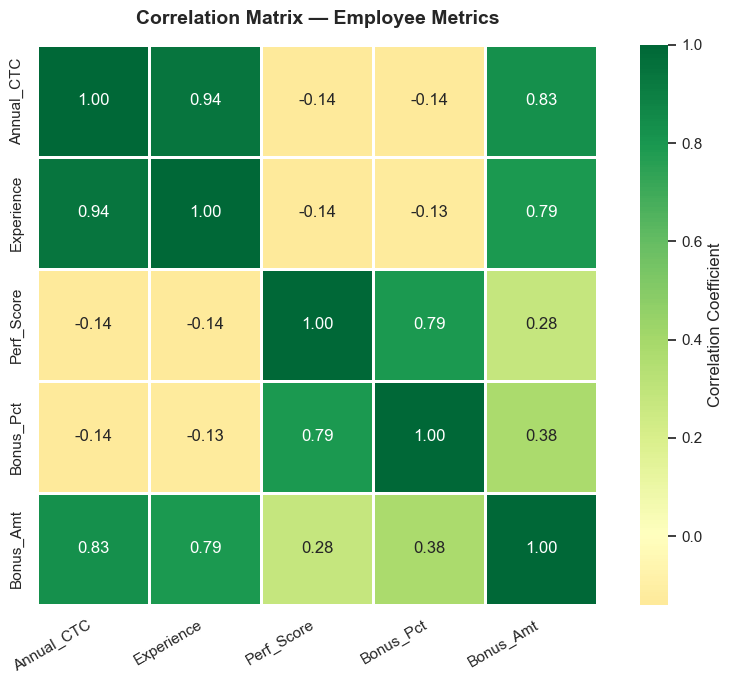

Key Insights from Correlation Matrix:
  CTC vs Experience:  0.94  — Strong +ve
  Bonus% vs Perf:     0.79  — Performance drives bonus


In [13]:
# Correlation heatmap for employee data
numeric_cols = employees[['Annual_CTC', 'Experience', 'Perf_Score', 'Bonus_Pct', 'Bonus_Amt']]
corr_matrix  = numeric_cols.corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values in each cell
    fmt='.2f',            # 2 decimal places
    cmap='RdYlGn',        # Red (negative) → Yellow (zero) → Green (positive)
    center=0,             # Centre the colour scale at 0
    square=True,
    linewidths=1,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Correlation Coefficient'}
)

ax.set_title('Correlation Matrix — Employee Metrics', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Key insights
print('Key Insights from Correlation Matrix:')
r_exp   = corr_matrix.loc['Annual_CTC', 'Experience']
r_perf  = corr_matrix.loc['Annual_CTC', 'Perf_Score']
r_bns   = corr_matrix.loc['Bonus_Pct',  'Perf_Score']
lbl_exp  = 'Strong +ve' if abs(r_exp)  > 0.5 else 'Moderate'
lbl_perf = 'Strong +ve' if abs(r_perf) > 0.5 else 'Moderate'
print(f'  CTC vs Experience:  {r_exp}  — {lbl_exp}')
print(f'  Bonus% vs Perf:     {corr_matrix.loc["Bonus_Pct","Perf_Score"]}  — Performance drives bonus')

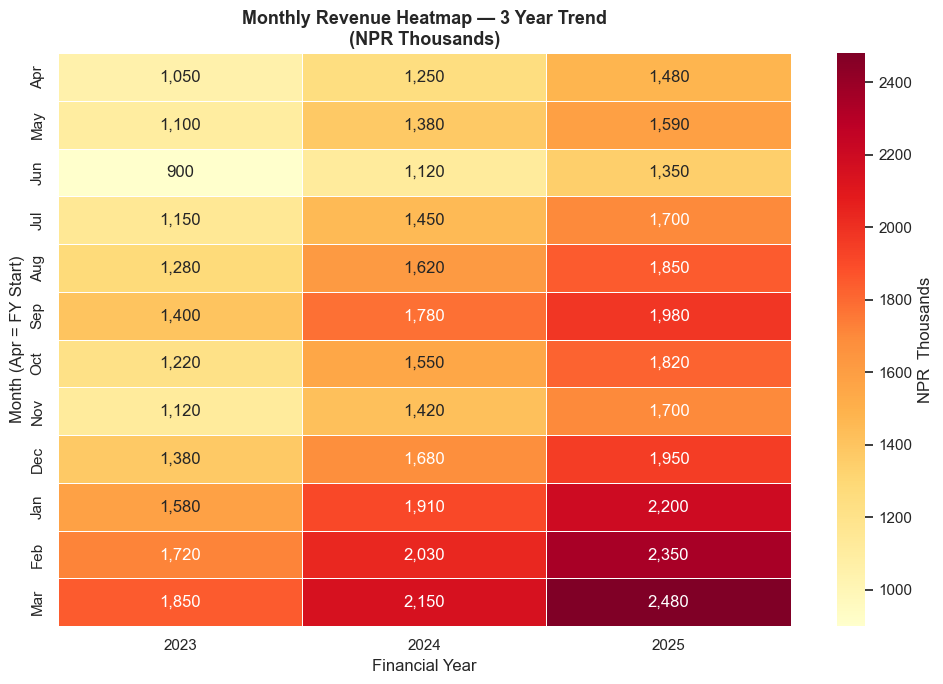

In [14]:
# Monthly revenue heatmap — very common in business analysis
# Simulate 3 years of monthly revenue data
np.random.seed(5)
years = [2023, 2024, 2025]
months_list = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

base    = 1200
trend   = 80    # ~80K growth per month over years
monthly_rev = {
    2023: [1050, 1100, 900, 1150, 1280, 1400, 1220, 1120, 1380, 1580, 1720, 1850],
    2024: [1250, 1380, 1120, 1450, 1620, 1780, 1550, 1420, 1680, 1910, 2030, 2150],
    2025: [1480, 1590, 1350, 1700, 1850, 1980, 1820, 1700, 1950, 2200, 2350, 2480],
}

rev_df = pd.DataFrame(monthly_rev, index=months_list)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(rev_df, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'NPR  Thousands'})

ax.set_title('Monthly Revenue Heatmap — 3 Year Trend\n(NPR Thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Month (Apr = FY Start)')

plt.tight_layout()
plt.show()

## Section 13: Pair Plot — Multi-variable Exploration

`sns.pairplot()` creates a **grid of scatter plots** for all pairs of numeric variables — ideal for initial data exploration. One line of code replaces many separate charts.

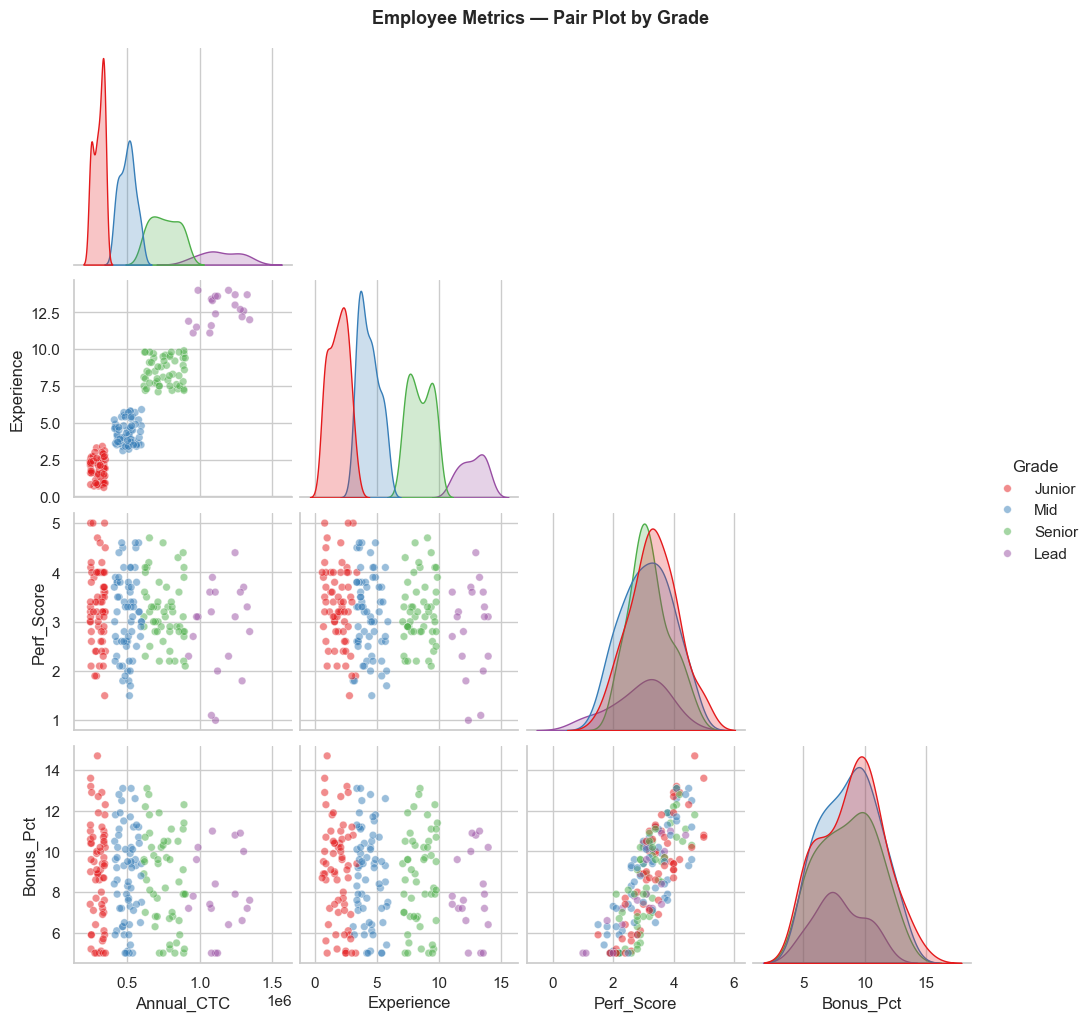

In [15]:
# Pair plot — all relationships in employee data at once
# Color-coded by Grade
pair_data = employees[['Annual_CTC', 'Experience', 'Perf_Score', 'Bonus_Pct', 'Grade']]

g = sns.pairplot(
    pair_data,
    hue='Grade',
    hue_order=['Junior', 'Mid', 'Senior', 'Lead'],
    palette='Set1',
    diag_kind='kde',     # Diagonal = KDE distribution
    plot_kws={'alpha': 0.5, 's': 30},
    corner=True          # Only lower triangle (avoids duplication)
)

g.fig.suptitle('Employee Metrics — Pair Plot by Grade', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## Section 14: Scatter with Regression — Relationships in Data

`sns.regplot()` and `sns.lmplot()` draw scatter plots with a **regression line** — shows the trend and whether two variables are truly related.

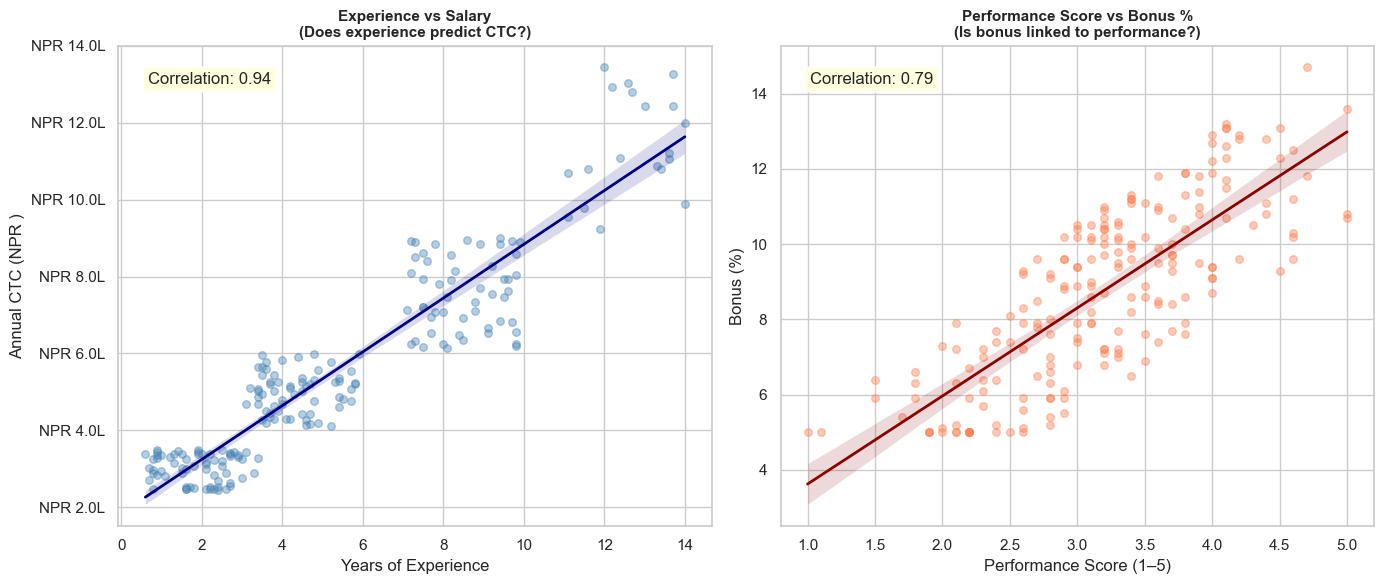

In [16]:
# regplot — does experience predict salary?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Experience vs CTC
sns.regplot(data=employees, x='Experience', y='Annual_CTC',
            scatter_kws={'alpha': 0.4, 's': 30, 'color': 'steelblue'},
            line_kws={'color': 'navy', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title('Experience vs Salary\n(Does experience predict CTC?)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Annual CTC (NPR )')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.1f}L'))

corr_exp_ctc = employees[['Experience', 'Annual_CTC']].corr().iloc[0, 1]
axes[0].text(0.05, 0.92, f'Correlation: {corr_exp_ctc:.2f}', transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Plot 2: Performance Score vs Bonus %
sns.regplot(data=employees, x='Perf_Score', y='Bonus_Pct',
            scatter_kws={'alpha': 0.4, 's': 30, 'color': 'coral'},
            line_kws={'color': 'darkred', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('Performance Score vs Bonus %\n(Is bonus linked to performance?)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Performance Score (1–5)')
axes[1].set_ylabel('Bonus (%)')

corr_perf_bonus = employees[['Perf_Score', 'Bonus_Pct']].corr().iloc[0, 1]
axes[1].text(0.05, 0.92, f'Correlation: {corr_perf_bonus:.2f}', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

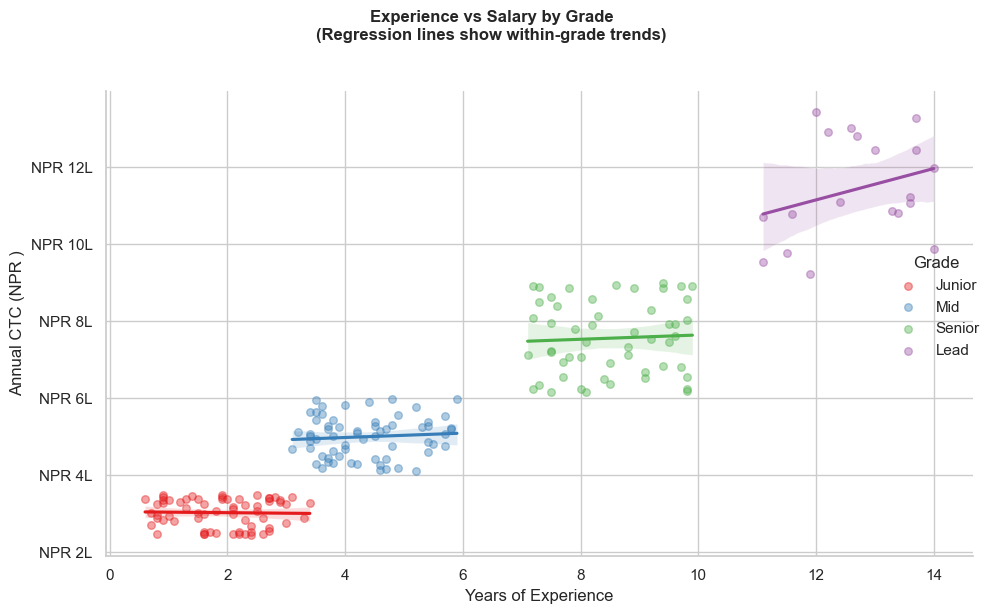

In [17]:
# lmplot — regression by subgroup (Grade)
g = sns.lmplot(
    data=employees,
    x='Experience',
    y='Annual_CTC',
    hue='Grade',
    hue_order=['Junior', 'Mid', 'Senior', 'Lead'],
    palette='Set1',
    scatter_kws={'alpha': 0.4, 's': 30},
    height=6, aspect=1.5
)

g.set_axis_labels('Years of Experience', 'Annual CTC (NPR )')
g.fig.suptitle('Experience vs Salary by Grade\n(Regression lines show within-grade trends)',
               y=1.02, fontsize=12, fontweight='bold')

# Format y-axis
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.0f}L'))

plt.tight_layout()
plt.show()

## Section 15: FacetGrid — Charts by Category

`FacetGrid` creates a grid of the same chart, **split by a categorical variable**. Like applying the same chart to each department, each quarter, etc.

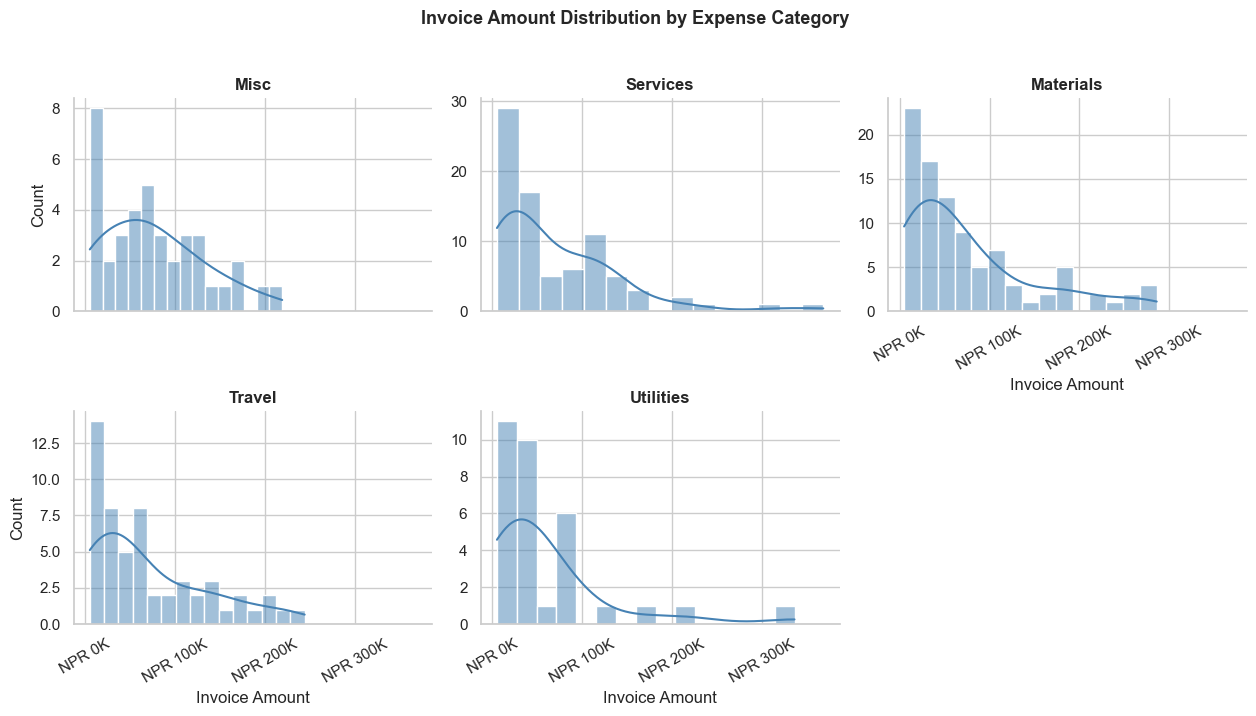

In [18]:
# Invoice amount distribution — one histogram per expense category
g = sns.FacetGrid(
    invoice_df,
    col='Category',
    col_wrap=3,          # 3 charts per row
    height=3.5,
    aspect=1.2,
    sharey=False         # Allow different y-axis scales per chart
)

g.map(sns.histplot, 'Amount', bins=15, color='steelblue', kde=True)

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'NPR {x/1000:.0f}K'))
    ax.tick_params(axis='x', rotation=30)

g.set_axis_labels('Invoice Amount', 'Count')
g.set_titles(col_template='{col_name}', fontweight='bold')
g.fig.suptitle('Invoice Amount Distribution by Expense Category', y=1.02, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 16: Seaborn + Matplotlib Together

Seaborn and Matplotlib work together seamlessly. Use Seaborn for the chart, Matplotlib for fine-tuning.

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/2995762040.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employees, x='Department', y='Annual_CTC',


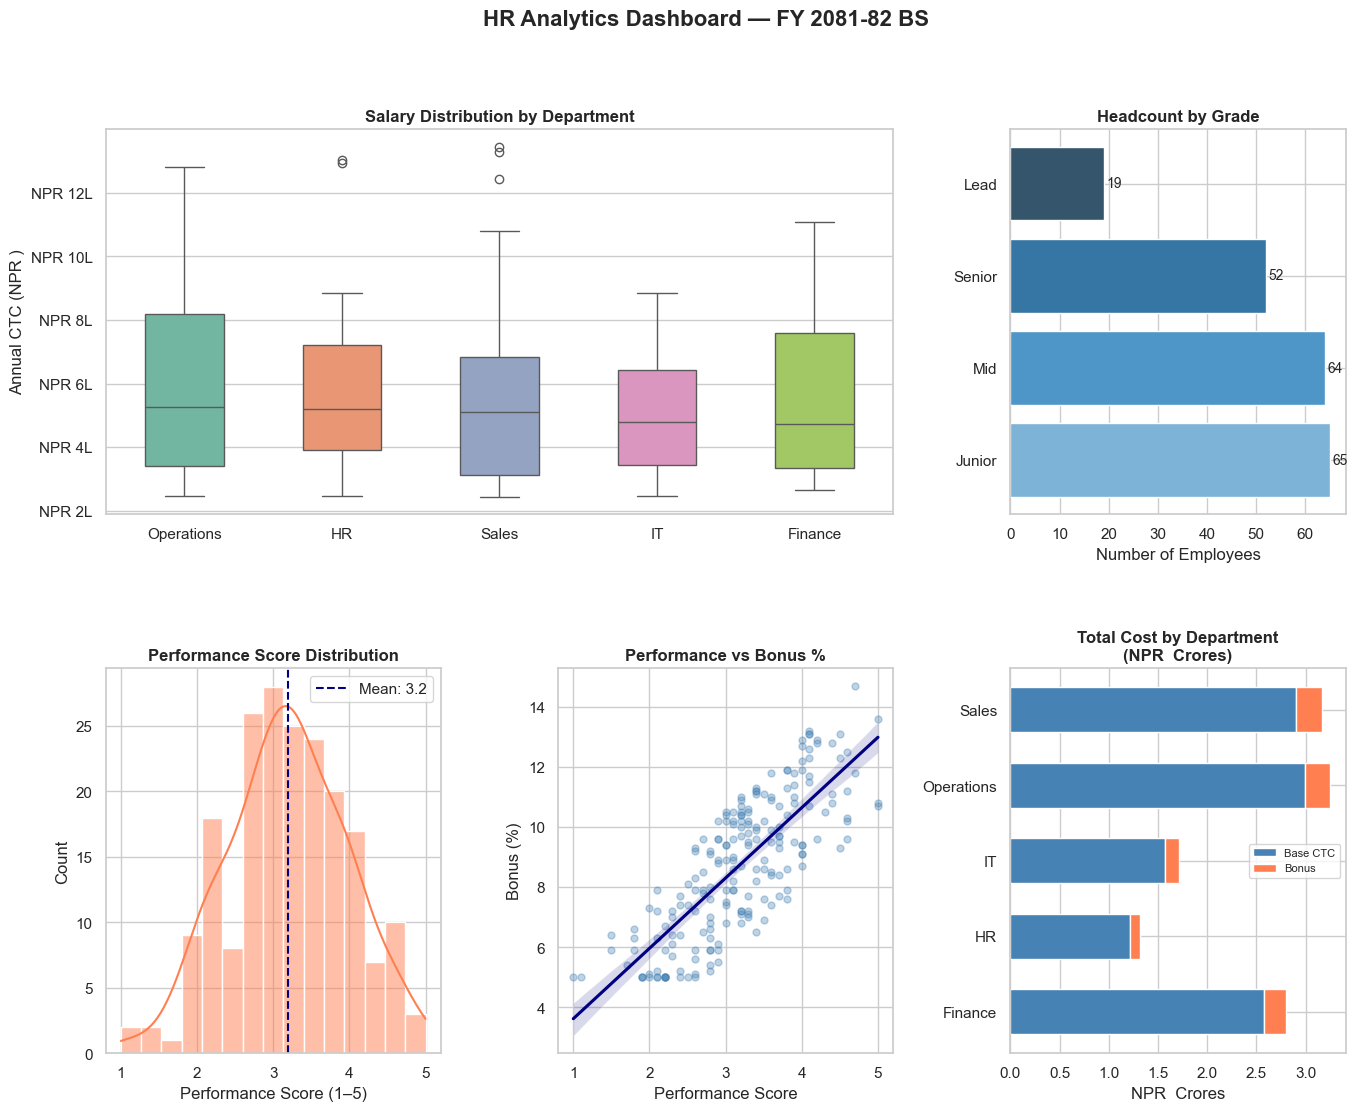

In [19]:
# Comprehensive HR Analytics Dashboard
fig = plt.figure(figsize=(16, 12))
fig.suptitle('HR Analytics Dashboard — FY 2081-82 BS', fontsize=16, fontweight='bold', y=0.98)

# Layout using gridspec
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# Chart 1: Salary by Department (box plot)
ax1 = fig.add_subplot(gs[0, 0:2])
dept_order = employees.groupby('Department')['Annual_CTC'].median().sort_values(ascending=False).index
sns.boxplot(data=employees, x='Department', y='Annual_CTC',
            order=dept_order, palette='Set2', ax=ax1, width=0.5)
ax1.set_title('Salary Distribution by Department', fontweight='bold')
ax1.set_ylabel('Annual CTC (NPR )')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/100000:.0f}L'))

# Chart 2: Headcount by Grade (count plot)
ax2 = fig.add_subplot(gs[0, 2])
grade_counts = employees['Grade'].value_counts().reindex(['Junior','Mid','Senior','Lead'])
ax2.barh(grade_counts.index, grade_counts.values,
         color=sns.color_palette('Blues_d', 4))
for i, v in enumerate(grade_counts.values):
    ax2.text(v + 0.5, i, str(v), va='center', fontsize=10)
ax2.set_title('Headcount by Grade', fontweight='bold')
ax2.set_xlabel('Number of Employees')

# Chart 3: Performance distribution
ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(data=employees, x='Perf_Score', bins=15, kde=True, color='coral', ax=ax3)
ax3.axvline(employees['Perf_Score'].mean(), color='navy', linestyle='--',
             label=f"Mean: {employees['Perf_Score'].mean():.1f}")
ax3.set_title('Performance Score Distribution', fontweight='bold')
ax3.set_xlabel('Performance Score (1–5)')
ax3.legend()

# Chart 4: Bonus % vs Perf regression
ax4 = fig.add_subplot(gs[1, 1])
sns.regplot(data=employees, x='Perf_Score', y='Bonus_Pct',
            scatter_kws={'alpha': 0.35, 's': 25, 'color': 'steelblue'},
            line_kws={'color': 'navy'}, ax=ax4)
ax4.set_title('Performance vs Bonus %', fontweight='bold')
ax4.set_xlabel('Performance Score')
ax4.set_ylabel('Bonus (%)')

# Chart 5: Dept cost breakdown (stacked bar)
ax5 = fig.add_subplot(gs[1, 2])
dept_cost = employees.groupby('Department')[['Annual_CTC', 'Bonus_Amt']].sum() / 1e7  # In NPR  Crores
dept_cost.plot(kind='barh', stacked=True, ax=ax5,
               color=['steelblue', 'coral'], width=0.6)
ax5.set_title('Total Cost by Department\n(NPR  Crores)', fontweight='bold')
ax5.set_xlabel('NPR  Crores')
ax5.set_ylabel('')
ax5.legend(['Base CTC', 'Bonus'], fontsize=8)

plt.show()

## Section 17: Practice Exercises

---

#### 🏋️ Exercise 1 — Invoice Outlier Analysis

Using the `invoice_df` dataset:
1. Create a box plot showing invoice amounts for each VAT rate (0% exempt, 13% standard — Nepal IRD classification)
2. Identify and print the invoices that are statistical outliers (above Q3 + 1.5×IQR)
3. Create a heatmap showing average invoice amount by Category and Status

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# (Re-run the data setup cell at the top if invoice_df is not available)

# Write your analysis here



#### 🏋️ Exercise 2 — Department-wise Financial Dashboard

Using the `employees` dataset, create a **2×2 subplot dashboard** with:
1. **Top-left**: Violin plot of salary by department
2. **Top-right**: Bar plot of average performance score by department
3. **Bottom-left**: Scatter of Experience vs Bonus Amount, coloured by Department
4. **Bottom-right**: Heatmap of average salary by Department and Grade

Add appropriate titles and axis labels.

In [21]:
# Write your dashboard here




---
### 💡 Solutions

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/81329947.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=invoice_df, x='VAT_Rate', y='Amount', palette='coolwarm', ax=axes[0],


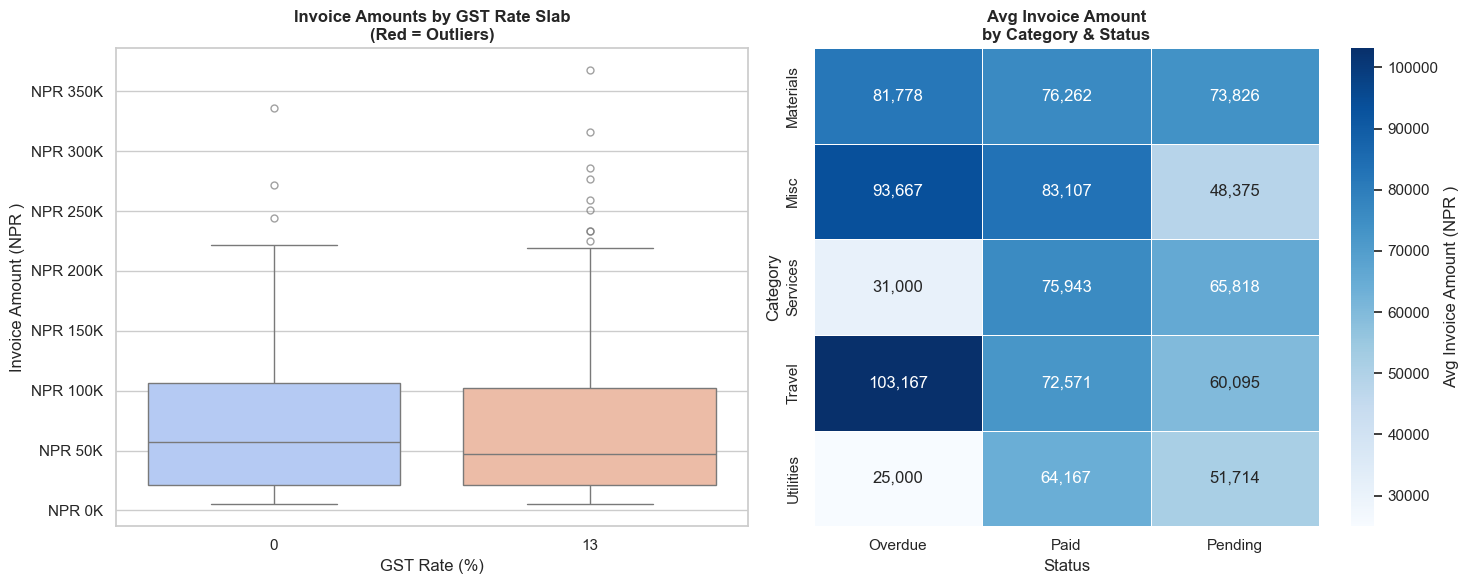

Outlier threshold: NPR 231,375
Outlier count: 11 (3.7% of invoices)
Total outlier value: NPR 3,075,000


In [22]:
# SOLUTION — Exercise 1: Invoice Outlier Analysis
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# (Rebuild dataset if needed)
np.random.seed(7)
m = 300
invoice_df = pd.DataFrame({
    'Amount':   np.random.exponential(75000, m).clip(5000, 600000).round(-3).astype(int),
    'Category': np.random.choice(['Materials','Services','Utilities','Travel','Misc'], m, p=[0.30,0.25,0.15,0.20,0.10]),
    'VAT_Rate': np.random.choice([0, 13], m, p=[0.15, 0.85]),
    'Status':   np.random.choice(['Paid','Pending','Overdue'], m, p=[0.65, 0.25, 0.10]),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot by GST rate
sns.boxplot(data=invoice_df, x='VAT_Rate', y='Amount', palette='coolwarm', ax=axes[0],
            flierprops=dict(marker='o', color='red', markersize=5, alpha=0.7))
axes[0].set_title('Invoice Amounts by GST Rate Slab\n(Red = Outliers)', fontweight='bold')
axes[0].set_xlabel('GST Rate (%)')
axes[0].set_ylabel('Invoice Amount (NPR )')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'NPR {y/1000:.0f}K'))

# Heatmap: Avg Amount by Category & Status
pivot = invoice_df.pivot_table(values='Amount', index='Category', columns='Status', aggfunc='mean').round(0)
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Avg Invoice Amount (NPR )'})
axes[1].set_title('Avg Invoice Amount\nby Category & Status', fontweight='bold')

plt.tight_layout()
plt.show()

# Identify outliers
Q1, Q3 = invoice_df['Amount'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
upper  = Q3 + 1.5 * IQR
outliers = invoice_df[invoice_df['Amount'] > upper]
print(f'Outlier threshold: NPR {upper:,.0f}')
print(f'Outlier count: {len(outliers)} ({len(outliers)/len(invoice_df)*100:.1f}% of invoices)')
print(f'Total outlier value: NPR {outliers["Amount"].sum():,.0f}')

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11210/3553043638.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=employees, x='Department', y='Annual_CTC', palette='pastel', ax=axes[0,0], inner='quartile')


TypeError: DataFrame.pivot_table() got an unexpected keyword argument 'columns_sort'

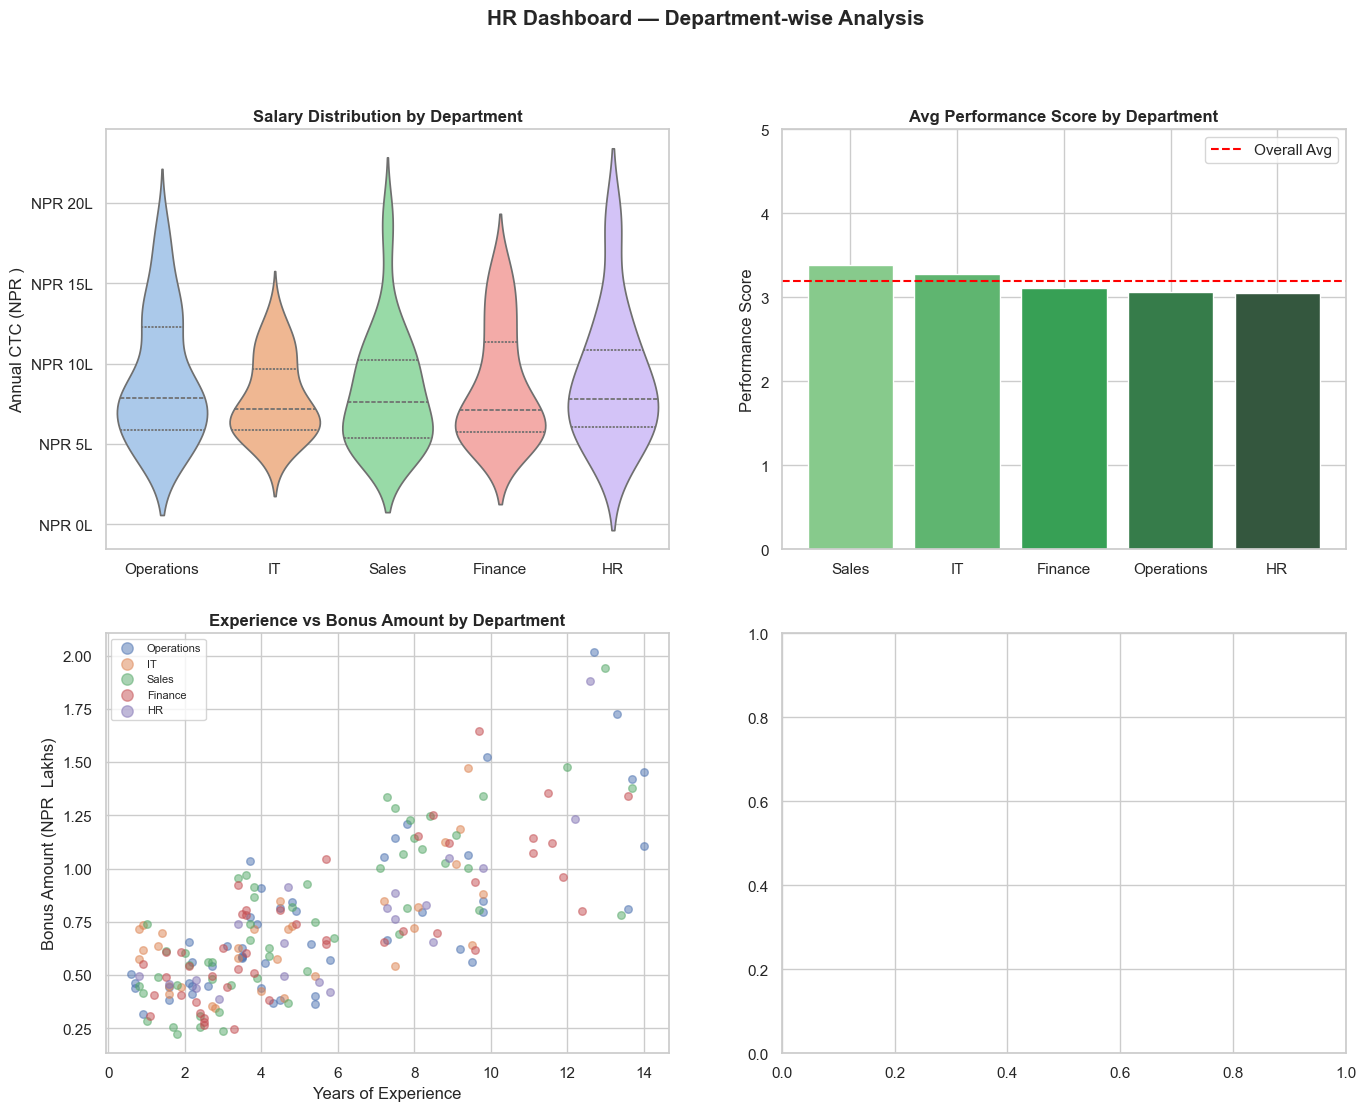

In [23]:
# SOLUTION — Exercise 2: Department-wise Dashboard
import seaborn as sns, matplotlib.pyplot as plt, pandas as pd, numpy as np

# Rebuild employees if needed (copy from data setup cell)
np.random.seed(42)
n = 200
departments = np.random.choice(['Finance','Operations','Sales','HR','IT'], n, p=[0.20,0.25,0.30,0.10,0.15])
grades      = np.random.choice(['Junior','Mid','Senior','Lead'], n, p=[0.35,0.30,0.25,0.10])
base_salary = {'Junior':480000,'Mid':720000,'Senior':1080000,'Lead':1560000}
salaries    = np.array([base_salary[g] * np.random.uniform(0.85, 1.25) for g in grades])
experience  = np.array([{'Junior':1.5,'Mid':4.0,'Senior':8.0,'Lead':12.0}[g]+np.random.uniform(-1,2) for g in grades]).clip(0,20)
performance = np.clip(np.random.normal(3.2, 0.8, n), 1, 5).round(1)
bonus_pct   = np.clip(performance*2.5+np.random.uniform(-2,3,n), 5, 25).round(1)
bonus_amt   = salaries * bonus_pct / 100
employees   = pd.DataFrame({'Department':departments,'Grade':grades,'Annual_CTC':salaries.round(0).astype(int),
                             'Experience':experience.round(1),'Perf_Score':performance,
                             'Bonus_Pct':bonus_pct,'Bonus_Amt':bonus_amt.round(0).astype(int)})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('HR Dashboard — Department-wise Analysis', fontsize=15, fontweight='bold')

# 1. Violin — salary by department
sns.violinplot(data=employees, x='Department', y='Annual_CTC', palette='pastel', ax=axes[0,0], inner='quartile')
axes[0,0].set_title('Salary Distribution by Department', fontweight='bold')
axes[0,0].set_ylabel('Annual CTC (NPR )')
axes[0,0].set_xlabel('')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'NPR {y/100000:.0f}L'))

# 2. Bar — avg performance score by dept
dept_perf = employees.groupby('Department')['Perf_Score'].mean().sort_values(ascending=False)
axes[0,1].bar(dept_perf.index, dept_perf.values, color=sns.color_palette('Greens_d', len(dept_perf)))
axes[0,1].axhline(employees['Perf_Score'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall Avg')
axes[0,1].set_title('Avg Performance Score by Department', fontweight='bold')
axes[0,1].set_ylabel('Performance Score')
axes[0,1].set_ylim(0, 5)
axes[0,1].legend()

# 3. Scatter — Experience vs Bonus
for dept in employees['Department'].unique():
    sub = employees[employees['Department'] == dept]
    axes[1,0].scatter(sub['Experience'], sub['Bonus_Amt']/100000, label=dept, alpha=0.5, s=30)
axes[1,0].set_title('Experience vs Bonus Amount by Department', fontweight='bold')
axes[1,0].set_xlabel('Years of Experience')
axes[1,0].set_ylabel('Bonus Amount (NPR  Lakhs)')
axes[1,0].legend(fontsize=8, markerscale=1.5)

# 4. Heatmap — avg salary by Dept × Grade
heat_data = employees.pivot_table(values='Annual_CTC', index='Department', columns='Grade',
                                   columns_sort=False,
                                   aggfunc='mean').reindex(columns=['Junior','Mid','Senior','Lead']) / 100000
sns.heatmap(heat_data.round(1), annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1],
            cbar_kws={'label': 'Avg CTC (NPR  Lakhs)'}, linewidths=0.5)
axes[1,1].set_title('Avg Salary (NPR L) by Dept × Grade', fontweight='bold')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 🎉 Module 5 Complete — And That's the Full Series!

### What you've learned in this module

| Chart | When to use |
|-------|-------------|
| `histplot` / `kdeplot` | Distribution of invoices, salaries, returns |
| `boxplot` | Outlier detection, salary ranges, audit flags |
| `violinplot` | Distribution shape by category |
| `barplot` | Mean comparison with confidence intervals |
| `countplot` | Frequency analysis by category |
| `heatmap` | Correlation, monthly trends, segment × category analysis |
| `pairplot` | Multi-variable exploration in one chart |
| `regplot` / `lmplot` | Trend and regression by group |
| `FacetGrid` | Same chart repeated by category |

---

### 🏆 Full Course Summary

| Module | Library | Key Skills |
|--------|---------|------------|
| 1 | Python | Variables, data types, loops, functions |
| 2 | NumPy | Arrays, vectorized math, NPV/IRR |
| 3 | Pandas | DataFrames, GroupBy, merge, Excel I/O |
| 4 | Matplotlib | Line, bar, pie, histogram, dashboard |
| 5 | Seaborn | Statistical charts, heatmaps, outlier detection |

---

### What's Next?

1. **Real project**: Apply these skills to your own firm's data
2. **openpyxl / xlsxwriter**: Create formatted Excel reports from Python
3. **reportlab / fpdf**: Generate professional PDF reports automatically
4. **scikit-learn**: Machine learning for fraud detection and risk scoring
5. **Streamlit / Dash**: Build interactive financial dashboards

> *"Data is the new audit trail. Python is the new working paper."*

---
*Python for CA Professionals — Module 5: Seaborn*  
*End of Introductory Series*